In [ ]:
import torch
import cv2
import matplotlib.pyplot as plt
from torchvision import transforms
from model import RoboBlockNet, BlocksDataset
from model_utils import *

def colorize_mask(mask_2d):
    H, W = mask_2d.shape
    color_mask = np.zeros((H, W, 3), dtype=np.uint8)
    
    # Get the same color wheel
    cmap = plt.get_cmap('hsv')
    
    # Loop through the possible classes and apply the math using your LABEL_MAP
    for class_id in LABEL_MAP.keys():
        # Same math formula to get the RGB values for this ID
        color_position = class_id / NUM_CLASSES
        rgba_color = cmap(color_position)
        rgb_255 = tuple(int(c * 255) for c in rgba_color[:3])
        
        # Find all pixels where the mask equals this class ID, and set them to the RGB color
        color_mask[mask_2d == class_id] = rgb_255
        
    return color_mask


def predict(image_path, model, device):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    img_tensor = torch.from_numpy(image).to(torch.float).permute(2, 0, 1)
    
    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ])
    
    # Apply transforms, add batch dim, and CRITICALLY: send input to the device (MPS)
    input_tensor = transform(img_tensor).unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(input_tensor) 
        
    # Get predictions, then CRITICALLY: bring the tensor back to the CPU for matplotlib
    predictions = output.squeeze(0).argmax(0).cpu()
    
    return predictions


Running inference on: mps
RoboBlockNet loaded successfully!


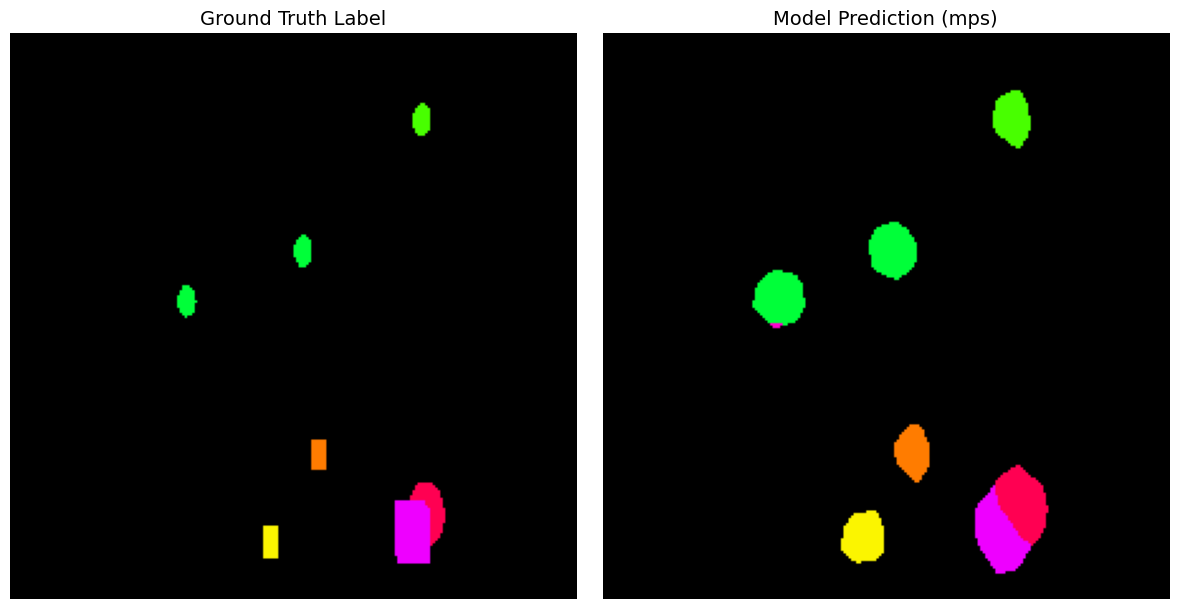

In [27]:

# 1. Setup Device (Your code)   
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f"Running inference on: {device}")

# 2. Initialize Model & Send to Device
model = RoboBlockNet().to(device)

# 3. Load Weights
weights_path = 'model_fcn_re101_cpu_402.pth'
# We use map_location=device to load the CPU-saved weights directly onto the Mac GPU
checkpoint = torch.load(weights_path, map_location=device, weights_only=False)

# 2. Check if the file contains the full model or just the weights
if isinstance(checkpoint, torch.nn.Module):
    # If they saved the whole model: torch.save(model, path)
    model = checkpoint 
else:
    # If they saved just the weights: torch.save(model.state_dict(), path)
    model.load_state_dict(checkpoint)

model.eval()
print("RoboBlockNet loaded successfully!")


testDataDir = "testImages"
imId = "3"
test_image_path = f"{testDataDir}/test_images/image_task-{imId}.png"
mask = predict(test_image_path, model, device)
mask_np = mask.numpy()


pred_colorized = colorize_mask(mask_np)


gt_image_path = f"{testDataDir}/segmentations/seg_{imId}.png" 
gt_mask = cv2.imread(gt_image_path, cv2.IMREAD_UNCHANGED)

# Ensure it was found
if gt_mask is None:
    print(f"Warning: Could not load ground truth image at {gt_image_path}")
else:
    # Resize GT to match the 224x224 output, strictly using nearest-neighbor so IDs aren't blended
    gt_mask_resized = cv2.resize(gt_mask, (224, 224), interpolation=cv2.INTER_NEAREST)
    
    # Colorize the Ground Truth
    gt_colorized = colorize_mask(gt_mask_resized)

    # 4. Plot them side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Left plot: Ground Truth
    axes[0].imshow(gt_colorized)
    axes[0].set_title("Ground Truth Label", fontsize=14)
    axes[0].axis('off')

    # Right plot: Model Prediction
    axes[1].imshow(pred_colorized)
    axes[1].set_title(f"Model Prediction ({device})", fontsize=14)
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

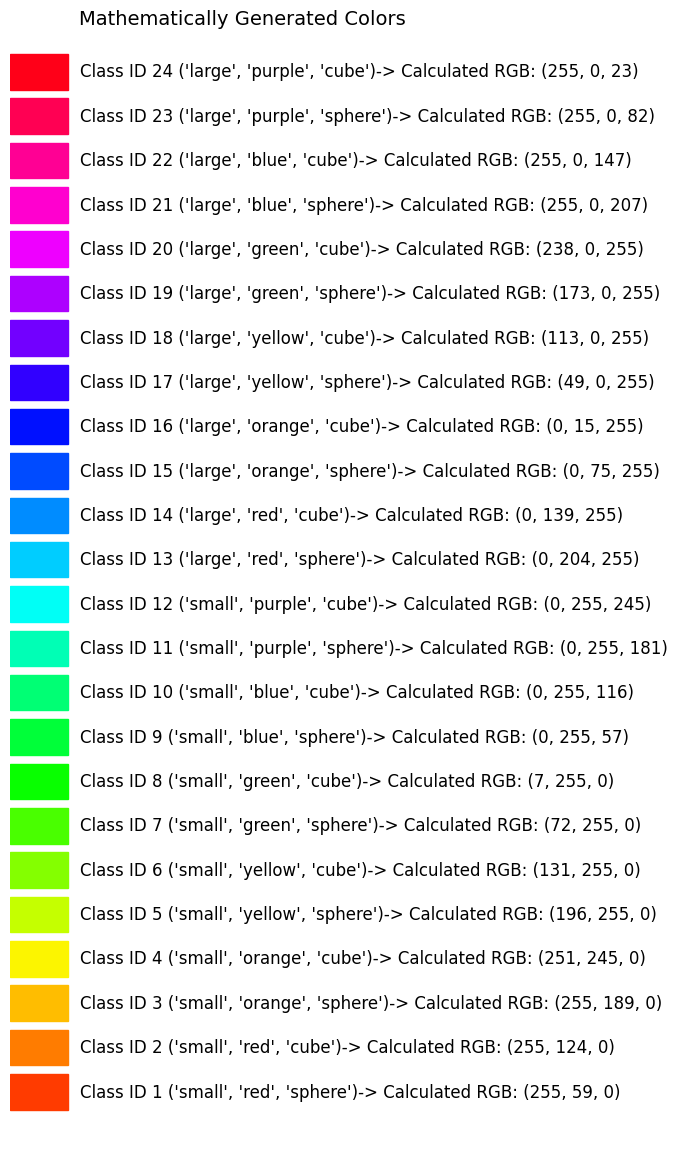

In [18]:
import matplotlib.pyplot as plt
import numpy as np


# Get a color wheel (HSV provides distinct, bright colors across a spectrum)
cmap = plt.get_cmap('hsv')

fig, ax = plt.subplots(figsize=(6, NUM_CLASSES * 0.6))

for class_id in LABEL_MAP.keys():
    # Calculate where on the color wheel this ID falls (0.0 to 1.0)
    color_position = class_id / NUM_CLASSES
    
    # Sample the color wheel (Returns an RGBA tuple from 0.0 to 1.0)
    rgba_color = cmap(color_position)
    
    # Convert the 0.0-1.0 float values into standard 0-255 RGB integers
    rgb_255 = tuple(int(c * 255) for c in rgba_color[:3])
    
    # Draw the color swatch using the normalized color
    ax.add_patch(plt.Rectangle((0, class_id), 1, 0.8, color=rgba_color))
    # Add text showing the Class ID and the generated RGB value
    label = f"Class ID {class_id} {LABEL_MAP[class_id]}-> Calculated RGB: {rgb_255}"
    ax.text(1.2, class_id + 0.4, label, va='center', fontsize=12)

# Clean up the plot
ax.set_xlim(0, 8)
ax.set_ylim(0, total_classes)
ax.axis('off') 
plt.title("Mathematically Generated Colors", fontsize=14, pad=15)
plt.show()